# Part 1 — Sprint Skeleton Visualiser

Loads every `.c3d` file and displays two views per participant:

- **SCR** (Single-frame Representation) — one snapshot at 50% of the trial  
- **MCR** (Multi-frame Representation) — 25 frames overlaid to show the motion envelope

Use this notebook to check that every file is on the correct axes **before** running Part 2.  
No PCA, no stride detection — raw positions only.

| Part | Notebook | What it does |
|------|----------|--------------|
| **1** | **Sprint_Ensemble_Viz.ipynb** | **Raw load → draw SCR + MCR for every file** |
| 2 | Kinematics_PCA.ipynb | Stride extraction + GCS alignment + fPCA |
| 3 | Sprint_ML_Analysis.ipynb | Machine learning |


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ezc3d

print("Imports OK")

Imports OK


In [6]:
C3D_DIR  = "/Users/kentsploch/Desktop/60m Data/All Sprint Trials/Sprint Trials in c3d"
FIG_DIR  = "/Users/kentsploch/Desktop/60m Data/Figures"

 
os.makedirs(FIG_DIR, exist_ok=True)

MK_T12   = 10                          # T12 spine sensor (0-based index)
FOOT_MKS = [52, 57, 58, 63]            # R_HEEL, R_TOE, L_HEEL, L_TOE
SCALE_MM = 1000.0                      # convert m → mm for plotting

AX_X = (-600,  600)                    # sagittal horizontal axis limits (mm)
AX_Z = (-500,  500)                    # frontal  horizontal axis limits (mm)
AX_Y = ( -50, 1800)                    # vertical axis limits (mm)

BONE_POLYS = [
    [2,3,5,4,2,6,7,3,7,8,6,8,9,10,11,14,16,21,12,15,11,15,21,15,22,15,12,22,16],
    [22,11],[21,11],
    [17,18,19,17,20,18,20,19,20,16],
    [21,23,24,29,24,21],[21,29,27,29,28,27],[24,27,24,28,27],[23,27,23,28,27],
    [27,33,28,33,34,33,35,33,34,27],
    [22,25,26,25,32,22],[22,26],
    [30,31,25,30,25,31,25,26,30,26,31,26],[32,30,31,30,32,31,32],
    [30,36,30,37,30,38,36,37,31,36,31,37,31,38,31],
    [39,40,39,41,39,42,41,40,42,47,40,47,41,47],[47,48,47,49],
    [40,48,40,49],[41,48,41,49],
    [48,49,53,48,53,54,53,55,53,56,57,56,58,53],
    [43,44,43,45,43,46,45,44,46],[50,46,50,45,50,44,50],
    [50,51,50,52,50],[44,51,44,52,44],[45,51,45,52,45],
    [51,52,51,59,52,59,60,59,60,59,62,59,61,62,63,62,64],
]

all_names = os.listdir(C3D_DIR)
c3d_files = sorted([os.path.join(C3D_DIR, f) for f in all_names if f.endswith(".c3d")])
print(f"Found {len(c3d_files)} C3D files")
print(f"Figures → {FIG_DIR}")

Found 31 C3D files
Figures → /Users/kentsploch/Desktop/60m Data/Figures


In [7]:
def load_c3d_raw(filepath):
    """Load a C3D file. Returns (markers, fs).
    markers : (n_frames, 64, 3) in metres — raw sensor positions, no rotation applied.
    fs      : frame rate in Hz.
    """
    c   = ezc3d.c3d(str(filepath))
    raw = c['data']['points'][:3].transpose(2, 1, 0)   # (frames, sensors, 3)

    if np.max(np.abs(raw)) > 50:
        raw = raw / 1000.0                              # mm → m

    n_frames, n_sensors, _ = raw.shape
    if n_sensors >= 64:
        markers = raw[:, :64, :]
    else:
        markers = np.zeros((n_frames, 64, 3))
        markers[:, :n_sensors, :] = raw                # pad if fewer than 64 sensors

    fs = float(c['header']['points']['frame_rate'])
    return markers, fs


print("load_c3d_raw defined.")


load_c3d_raw defined.


In [8]:
def prepare_for_display(markers):
    """Shift Y so the lowest foot sensor = 0 (ground), then convert m → mm."""
    out = markers.copy()
    out[:, :, 1] -= np.min(out[:, FOOT_MKS, 1])       # ground offset
    return out * SCALE_MM                               # m → mm


def draw_skeleton(ax, markers_mm, frame_idx, plane="sagittal",
                  color="#1f77b4", lw=0.9, ms=2.0, alpha=1.0):
    """Draw one frame of a skeleton onto ax.
    plane: 'sagittal' (X–Y side view)  or  'frontal' (Z–Y front view).
    """
    pts = markers_mm[frame_idx].copy()
    if plane == "sagittal":
        pts[:, 0] -= pts[MK_T12, 0]                    # centre horizontally on T12
        h, v = pts[:, 0], pts[:, 1]
    else:                                               # frontal
        pts[:, 2] -= pts[MK_T12, 2]
        h, v = pts[:, 2], pts[:, 1]

    ax.scatter(h, v, s=ms, c=[color], zorder=3, linewidths=0, alpha=alpha)
    for poly in BONE_POLYS:
        idx0 = [i - 1 for i in poly]                   # 1-based → 0-based
        ax.plot(h[idx0], v[idx0], color=color, lw=lw,
                alpha=alpha, solid_capstyle="round", zorder=2)


print("Drawing helpers defined.")


Drawing helpers defined.


[31/31] SB92-001


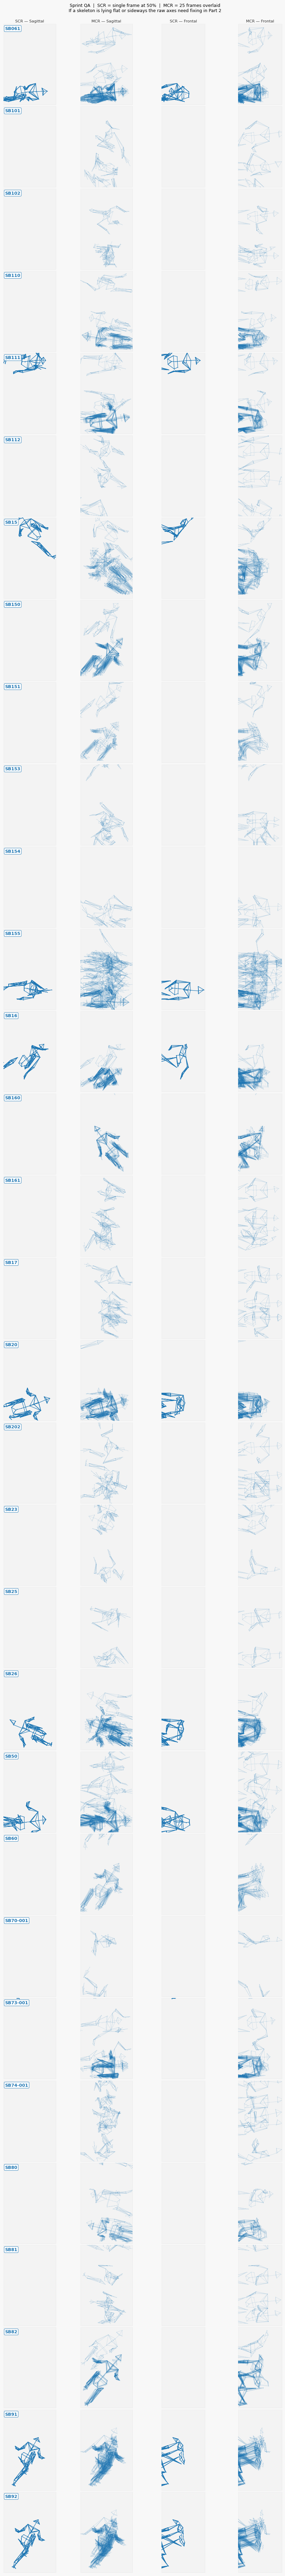

Saved : QA_skeleton_grid.png
Loaded: 31/31   |   Failed: 0


In [9]:
def _style_panel(ax, xlim, ylim):
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)


N_MCR       = 25
COL_HEADERS = ["SCR — Sagittal", "MCR — Sagittal", "SCR — Frontal", "MCR — Frontal"]
COL_PLANES  = ["sagittal",       "sagittal",        "frontal",       "frontal"]
COL_LIMITS  = [(AX_X, AX_Y),     (AX_X, AX_Y),      (AX_Z, AX_Y),    (AX_Z, AX_Y)]

all_names = os.listdir(C3D_DIR)
c3d_files = sorted([os.path.join(C3D_DIR, f) for f in all_names if f.endswith(".c3d")])
N = len(c3d_files)

if N == 0:
    print("No .c3d files found — check C3D_DIR in Cell 2.")
else:
    fig, axes = plt.subplots(N, 4, figsize=(4 * 2.4, N * 2.4), squeeze=False)
    fig.patch.set_facecolor("#f8f8f8")

    failed = []
    for i, fpath in enumerate(c3d_files):
        pid = os.path.splitext(os.path.basename(fpath))[0]
        print(f"[{i+1}/{N}] {pid}", end="\r")

        try:
            markers, fs = load_c3d_raw(fpath)
            mm = prepare_for_display(markers)
            n  = mm.shape[0]

            scr_frame  = int(n * 0.50)
            mcr_frames = np.linspace(0, n - 1, N_MCR).astype(int)

            for j, (plane, (xlim, ylim)) in enumerate(zip(COL_PLANES, COL_LIMITS)):
                ax = axes[i, j]
                ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                                color="#e8e8e8", zorder=0, alpha=0.5)

                if j % 2 == 0:                          # SCR
                    draw_skeleton(ax, mm, scr_frame, plane=plane)
                else:                                   # MCR overlay
                    for f in mcr_frames:
                        draw_skeleton(ax, mm, f, plane=plane,
                                      alpha=0.18, lw=0.6, ms=1.0)

                _style_panel(ax, xlim, ylim)
                if i == 0:
                    ax.set_title(COL_HEADERS[j], fontsize=8, pad=4, color="#333333")

            axes[i, 0].text(0.03, 0.97, pid,
                            transform=axes[i, 0].transAxes,
                            fontsize=9, fontweight="bold", color="#1f77b4",
                            ha="left", va="top",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                      edgecolor="#1f77b4", lw=0.7, alpha=0.95))

        except Exception as e:
            failed.append((pid, str(e)))
            for j, (xlim, ylim) in enumerate(COL_LIMITS):
                ax = axes[i, j]
                ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                                color="#ffe8e8", zorder=0, alpha=0.5)
                ax.text(0.5, 0.5, f"FAILED\n{e.__class__.__name__}",
                        ha="center", va="center", fontsize=7, color="red",
                        transform=ax.transAxes)
                _style_panel(ax, xlim, ylim)
            axes[i, 0].text(0.03, 0.97, pid,
                            transform=axes[i, 0].transAxes,
                            fontsize=9, fontweight="bold", color="red",
                            ha="left", va="top",
                            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                      edgecolor="red", lw=0.7, alpha=0.95))

    print()
    fig.suptitle(
        "Sprint QA  |  SCR = single frame at 50%  |  MCR = 25 frames overlaid\n"
        "If a skeleton is lying flat or sideways the raw axes need fixing in Part 2",
        fontsize=9, y=1.001,
    )
    plt.tight_layout(pad=0.4, h_pad=0.3, w_pad=0.2)

    out_path = os.path.join(FIG_DIR, "QA_skeleton_grid.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved : {os.path.basename(out_path)}")
    print(f"Loaded: {N - len(failed)}/{N}   |   Failed: {len(failed)}")
    for pid, err in failed:
        print(f"  ✗ {pid}: {err}")

## PCA-Aligned Visualisation

Rotates every file into a consistent Global Coordinate System (X = forward, Y = up, Z = lateral)
using PCA on a single reference frame + centroid displacement for forward direction.
Based on Chris Velluci's `pca_xsens_align.m`.

In [10]:
def pca_align(markers):
    """Rotate markers into GCS: X=forward, Y=up, Z=lateral.
    Uses mid-frame PCA for vertical, centroid displacement for forward.
    """
    n_frames = markers.shape[0]
    mid = n_frames // 2
    ref = markers[mid]                          # (64, 3) — reference frame
    centroid = ref.mean(axis=0)                 # (3,)

    cov_mat = np.cov((ref - centroid).T)        # 3×3 covariance of marker cloud
    vals, vecs = np.linalg.eigh(cov_mat)        # eigenvalues ascending
    y_ax = vecs[:, 2].copy()                    # largest eigenvalue = body height → vertical

    c_start = markers[:10].mean(axis=(0, 1))    # centroid of first 10 frames
    c_end   = markers[-10:].mean(axis=(0, 1))   # centroid of last 10 frames
    disp = c_end - c_start                      # displacement = travel direction
    disp_h = disp - np.dot(disp, y_ax) * y_ax   # remove vertical component

    if np.linalg.norm(disp_h) > 0.01:           # enough horizontal travel
        x_ax = disp_h / np.linalg.norm(disp_h)
    else:
        x_ax = vecs[:, 1].copy()                # fallback to PC2

    z_ax = np.cross(x_ax, y_ax)                 # lateral = cross(forward, up)
    z_ax = z_ax / np.linalg.norm(z_ax)
    x_ax = np.cross(y_ax, z_ax)                 # recompute for orthogonality
    x_ax = x_ax / np.linalg.norm(x_ax)

    if np.dot(ref[MK_T12] - ref[FOOT_MKS].mean(axis=0), y_ax) < 0:  # Y must point UP
        y_ax = -y_ax
        z_ax = -z_ax

    if np.linalg.norm(disp_h) > 0.01 and np.dot(disp, x_ax) < 0:    # X must be forward
        x_ax = -x_ax
        z_ax = -z_ax

    R = np.array([x_ax, y_ax, z_ax])            # 3×3 rotation matrix
    centred = markers - centroid                 # centre on body before rotating
    return centred @ R.T                         # (n_frames, 64, 3) body-relative rotated


def prepare_aligned(markers):
    """Per-frame ground offset + m→mm. Each frame's lowest foot marker → Y=0."""
    out = markers.copy()
    foot_min = out[:, FOOT_MKS, 1].min(axis=1, keepdims=True)  # (n_frames, 1)
    out[:, :, 1] -= foot_min                    # per-frame vertical shift
    return out * SCALE_MM


print("pca_align + prepare_aligned defined.")

pca_align + prepare_aligned defined.


[31/31] aligning SB92-001
Auto limits — sag H: (-812, 1574), frt H: (-638, 719), vert: (-174, 2053)


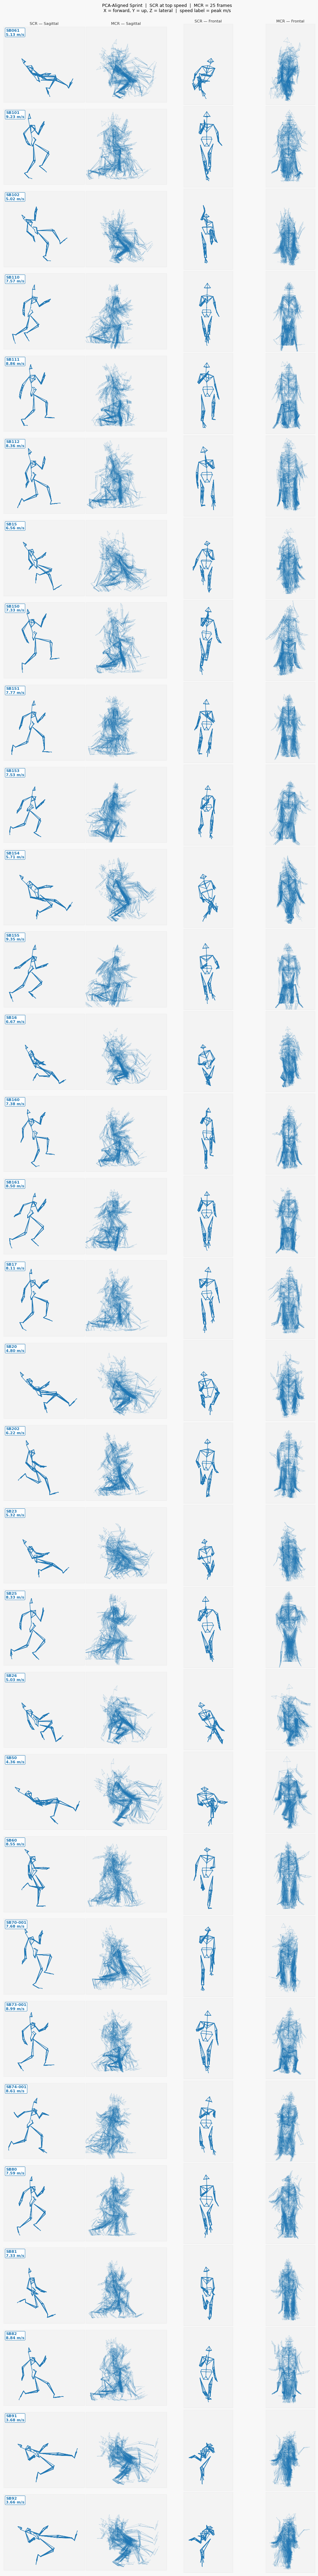

Saved : QA_skeleton_grid_top_speed.png
Aligned: 31/31   |   Failed: 0


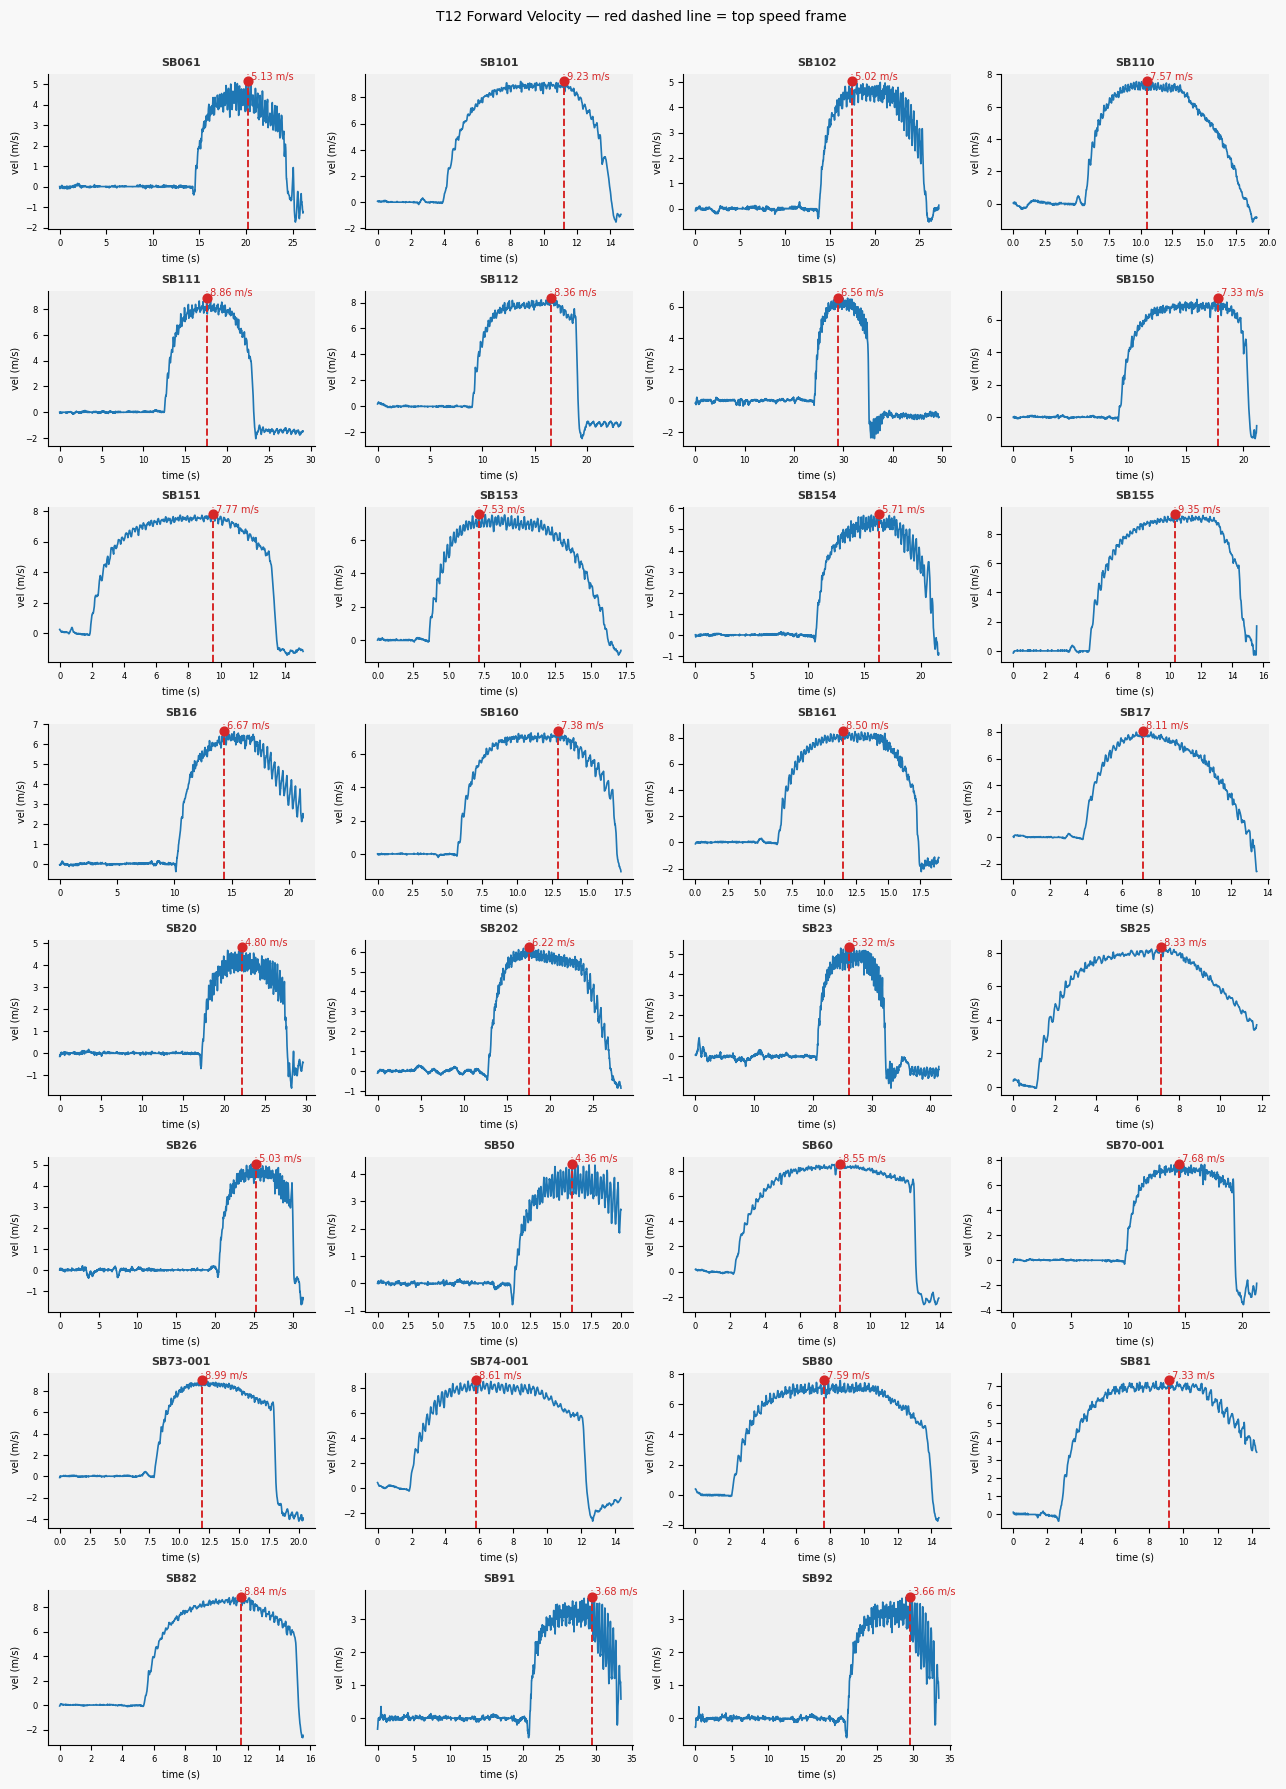

Saved : velocity_profiles_top_speed.png


In [11]:
def find_top_speed_frame(aligned_m, fs):
    """Return (frame_idx, velocity_array_m_s) using T12 forward (X) position.
    Uses np.gradient for smooth central differences.
    Trims the first/last 5 frames to avoid boundary artefacts from differentiation.
    """
    x_pos  = aligned_m[:, MK_T12, 0]            # T12 forward position (m)
    vel    = np.gradient(x_pos, 1.0 / fs)        # m/s, centred differences
    margin = 5
    safe   = vel[margin:-margin]
    peak   = int(np.argmax(safe)) + margin       # absolute frame index
    return peak, vel


# ── Pass 1: load, align, find top-speed frame, collect axis limits ────────────
all_names = os.listdir(C3D_DIR)
c3d_files = sorted([os.path.join(C3D_DIR, f) for f in all_names if f.endswith(".c3d")])
N = len(c3d_files)

loaded   = []   # (pid, mm_mm, scr_frame, vel_m_s, fs)
failed_a = []

for i, fpath in enumerate(c3d_files):
    pid = os.path.splitext(os.path.basename(fpath))[0]
    print(f"[{i+1}/{N}] aligning {pid}", end="\r")
    try:
        markers, fs  = load_c3d_raw(fpath)
        aligned      = pca_align(markers)
        scr_frame, vel = find_top_speed_frame(aligned, fs)
        mm           = prepare_aligned(aligned)
        loaded.append((pid, mm, scr_frame, vel, fs))
    except Exception as e:
        loaded.append((pid, None, None, None, None))
        failed_a.append((pid, str(e)))

# ── auto-scale axis limits using the top-speed frame ─────────────────────────
all_sag_h, all_frt_h, all_v = [], [], []
for pid, mm, scr_frame, vel, fs in loaded:
    if mm is None:
        continue
    pts = mm[scr_frame].copy()
    all_sag_h.extend((pts[:, 0] - pts[MK_T12, 0]).tolist())
    all_frt_h.extend((pts[:, 2] - pts[MK_T12, 2]).tolist())
    all_v.extend(pts[:, 1].tolist())

PAD    = 150
AX_X_A = (min(all_sag_h) - PAD, max(all_sag_h) + PAD)
AX_Z_A = (min(all_frt_h) - PAD, max(all_frt_h) + PAD)
AX_Y_A = (min(all_v)     - PAD, max(all_v)     + PAD)

print(f"\nAuto limits — sag H: ({AX_X_A[0]:.0f}, {AX_X_A[1]:.0f}), "
      f"frt H: ({AX_Z_A[0]:.0f}, {AX_Z_A[1]:.0f}), "
      f"vert: ({AX_Y_A[0]:.0f}, {AX_Y_A[1]:.0f})")

# ── Pass 2: skeleton grid — SCR at top speed ──────────────────────────────────
COL_LIMITS_A = [(AX_X_A, AX_Y_A), (AX_X_A, AX_Y_A), (AX_Z_A, AX_Y_A), (AX_Z_A, AX_Y_A)]

fig2, axes2 = plt.subplots(N, 4, figsize=(4 * 2.4, N * 2.4), squeeze=False)
fig2.patch.set_facecolor("#f8f8f8")

for i, (pid, mm, scr_frame, vel, fs) in enumerate(loaded):
    if mm is not None:
        n          = mm.shape[0]
        mcr_frames = np.linspace(0, n - 1, N_MCR).astype(int)
        top_speed  = vel[scr_frame] if vel is not None else float("nan")

        for j, (plane, (xlim, ylim)) in enumerate(zip(COL_PLANES, COL_LIMITS_A)):
            ax = axes2[i, j]
            ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                            color="#e8e8e8", zorder=0, alpha=0.5)
            if j % 2 == 0:                       # SCR at top speed
                draw_skeleton(ax, mm, scr_frame, plane=plane)
            else:                                # MCR overlay
                for f in mcr_frames:
                    draw_skeleton(ax, mm, f, plane=plane, alpha=0.18, lw=0.6, ms=1.0)
            _style_panel(ax, xlim, ylim)
            if i == 0:
                ax.set_title(COL_HEADERS[j], fontsize=8, pad=4, color="#333333")

        label = f"{pid}\n{top_speed:.2f} m/s"
        axes2[i, 0].text(0.03, 0.97, label,
                         transform=axes2[i, 0].transAxes,
                         fontsize=8, fontweight="bold", color="#1f77b4",
                         ha="left", va="top",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                   edgecolor="#1f77b4", lw=0.7, alpha=0.95))
    else:
        for j, (xlim, ylim) in enumerate(COL_LIMITS_A):
            ax = axes2[i, j]
            ax.fill_between([xlim[0], xlim[1]], ylim[0], ylim[1],
                            color="#ffe8e8", zorder=0, alpha=0.5)
            ax.text(0.5, 0.5, "FAILED", ha="center", va="center",
                    fontsize=7, color="red", transform=ax.transAxes)
            _style_panel(ax, xlim, ylim)
        axes2[i, 0].text(0.03, 0.97, pid,
                         transform=axes2[i, 0].transAxes,
                         fontsize=9, fontweight="bold", color="red",
                         ha="left", va="top",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                                   edgecolor="red", lw=0.7, alpha=0.95))

fig2.suptitle(
    "PCA-Aligned Sprint  |  SCR at top speed  |  MCR = 25 frames\n"
    "X = forward, Y = up, Z = lateral  |  speed label = peak m/s",
    fontsize=9, y=1.001,
)
plt.tight_layout(pad=0.4, h_pad=0.3, w_pad=0.2)

out_path2 = os.path.join(FIG_DIR, "QA_skeleton_grid_top_speed.png")
fig2.savefig(out_path2, dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print(f"Saved : {os.path.basename(out_path2)}")
print(f"Aligned: {N - len(failed_a)}/{N}   |   Failed: {len(failed_a)}")
for pid, err in failed_a:
    print(f"  ✗ {pid}: {err}")

# ── Pass 3: velocity time-series figure ───────────────────────────────────────
n_ok     = sum(1 for _, mm, *_ in loaded if mm is not None)
n_cols_v = min(4, n_ok)
n_rows_v = int(np.ceil(n_ok / n_cols_v))

fig3, axes3 = plt.subplots(n_rows_v, n_cols_v,
                            figsize=(n_cols_v * 3.2, n_rows_v * 2.2),
                            squeeze=False)
fig3.patch.set_facecolor("#f8f8f8")

plot_idx = 0
for pid, mm, scr_frame, vel, fs in loaded:
    if mm is None:
        continue
    r, c = divmod(plot_idx, n_cols_v)
    ax   = axes3[r, c]
    t    = np.arange(len(vel)) / fs

    ax.plot(t, vel, color="#1f77b4", lw=1.2)
    ax.axvline(scr_frame / fs, color="#d62728", lw=1.4, ls="--")
    ax.scatter([scr_frame / fs], [vel[scr_frame]],
               color="#d62728", s=40, zorder=5)
    ax.text(scr_frame / fs, vel[scr_frame],
            f" {vel[scr_frame]:.2f} m/s",
            fontsize=7, color="#d62728", va="bottom")

    ax.set_title(pid, fontsize=8, fontweight="bold", color="#333333")
    ax.set_xlabel("time (s)", fontsize=7)
    ax.set_ylabel("vel (m/s)", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_facecolor("#f0f0f0")

    plot_idx += 1

# hide any unused subplots
for k in range(plot_idx, n_rows_v * n_cols_v):
    r, c = divmod(k, n_cols_v)
    axes3[r, c].set_visible(False)

fig3.suptitle("T12 Forward Velocity — red dashed line = top speed frame",
              fontsize=10, y=1.01)
plt.tight_layout(pad=0.6, h_pad=0.8, w_pad=0.5)

out_path3 = os.path.join(FIG_DIR, "velocity_profiles_top_speed.png")
fig3.savefig(out_path3, dpi=150, bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print(f"Saved : {os.path.basename(out_path3)}")